# 05. Model Comparison, Synthesis & Decision Analysis
**Author**: Yordanos Andargachew (Phone: `+251 952 190 305`)  
**Project**: Bank Loan Risk Prediction System  

---

## 1. Overview & Evaluation Framework
In this notebook, we perform a rigorous head-to-head comparison between our **Linear Baseline (Logistic Regression)** and our **Advanced Non-Linear Ensemble (Random Forest)** on the 20% holdout test dataset.

In [1]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc
)
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("."))

from src.preprocessor import CreditDataPreprocessor

# Load dataset and prepare test split
data_path = os.path.join("..", "data", "dataset.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("data", "dataset.csv")

df = pd.read_csv(data_path)
X = df.drop(columns=['Risk'])
y = CreditDataPreprocessor.encode_target(df['Risk'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Load artifacts
models_dir = os.path.join("..", "models")
if not os.path.exists(models_dir):
    models_dir = "models"

preprocessor = CreditDataPreprocessor.load(os.path.join(models_dir, "preprocessor.pkl"))
lr_model = joblib.load(os.path.join(models_dir, "logistic_regression.pkl"))
rf_model = joblib.load(os.path.join(models_dir, "random_forest.pkl"))

X_test_trans = preprocessor.transform(X_test)
print("Artifacts Loaded and Test Set Preprocessed Successfully!")

Artifacts Loaded and Test Set Preprocessed Successfully!


## 2. Side-by-Side Performance Metrics Table

In [2]:
# Compute predictions
lr_pred = lr_model.predict(X_test_trans)
lr_proba = lr_model.predict_proba(X_test_trans)[:, 1]

rf_pred = rf_model.predict(X_test_trans)
rf_proba = rf_model.predict_proba(X_test_trans)[:, 1]

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Bad Risk)", "Recall (Bad Risk)", "F1-Score", "ROC-AUC"],
    "Logistic Regression (Baseline)": [
        f"{accuracy_score(y_test, lr_pred):.4f}",
        f"{precision_score(y_test, lr_pred):.4f}",
        f"{recall_score(y_test, lr_pred):.4f}",
        f"{f1_score(y_test, lr_pred):.4f}",
        f"{roc_auc_score(y_test, lr_proba):.4f}",
    ],
    "Random Forest (Advanced)": [
        f"{accuracy_score(y_test, rf_pred):.4f}",
        f"{precision_score(y_test, rf_pred):.4f}",
        f"{recall_score(y_test, rf_pred):.4f}",
        f"{f1_score(y_test, rf_pred):.4f}",
        f"{roc_auc_score(y_test, rf_proba):.4f}",
    ]
})

print("=== Side-by-Side Model Performance Comparison ===")
comparison_df

=== Side-by-Side Model Performance Comparison ===


,Metric,Logistic Regression (Baseline),Random Forest (Advanced)
0,Accuracy,0.7150,0.7000
1,Precision (Bad Risk),0.5172,0.5000
2,Recall (Bad Risk),0.7500,0.7167
3,F1-Score,0.6122,0.5890
4,ROC-AUC,0.7615,0.7844


## 3. Side-by-Side Confusion Matrix Comparison

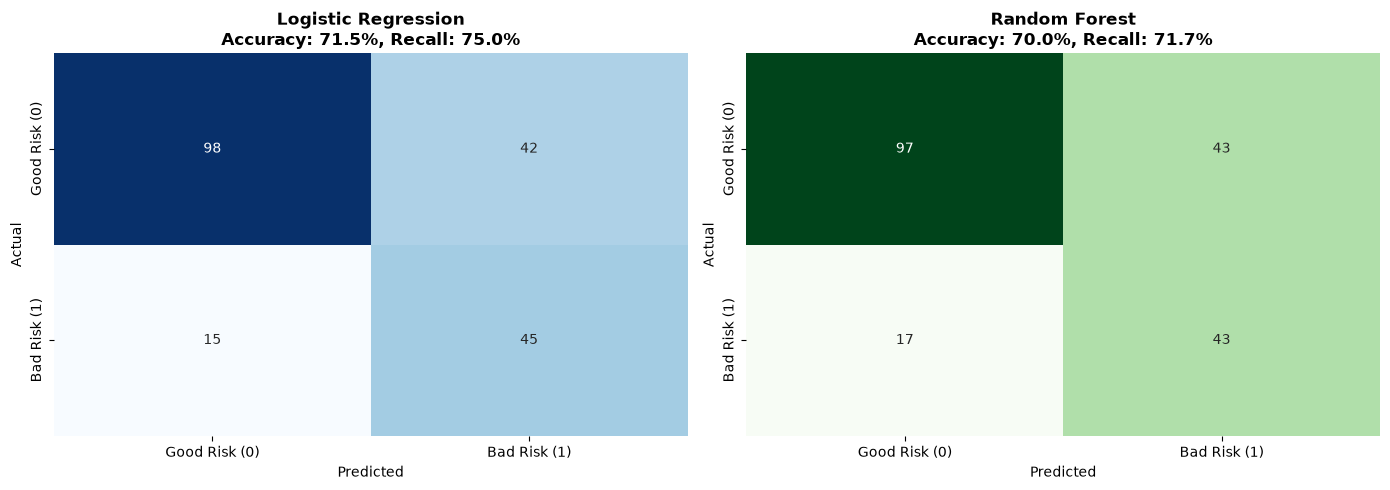

In [3]:
lr_cm = confusion_matrix(y_test, lr_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Good Risk (0)', 'Bad Risk (1)'],
            yticklabels=['Good Risk (0)', 'Bad Risk (1)'], cbar=False)
axes[0].set_title(f"Logistic Regression\nAccuracy: {accuracy_score(y_test, lr_pred):.1%}, Recall: {recall_score(y_test, lr_pred):.1%}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Good Risk (0)', 'Bad Risk (1)'],
            yticklabels=['Good Risk (0)', 'Bad Risk (1)'], cbar=False)
axes[1].set_title(f"Random Forest\nAccuracy: {accuracy_score(y_test, rf_pred):.1%}, Recall: {recall_score(y_test, rf_pred):.1%}", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 4. Combined ROC-AUC and Precision-Recall Curves

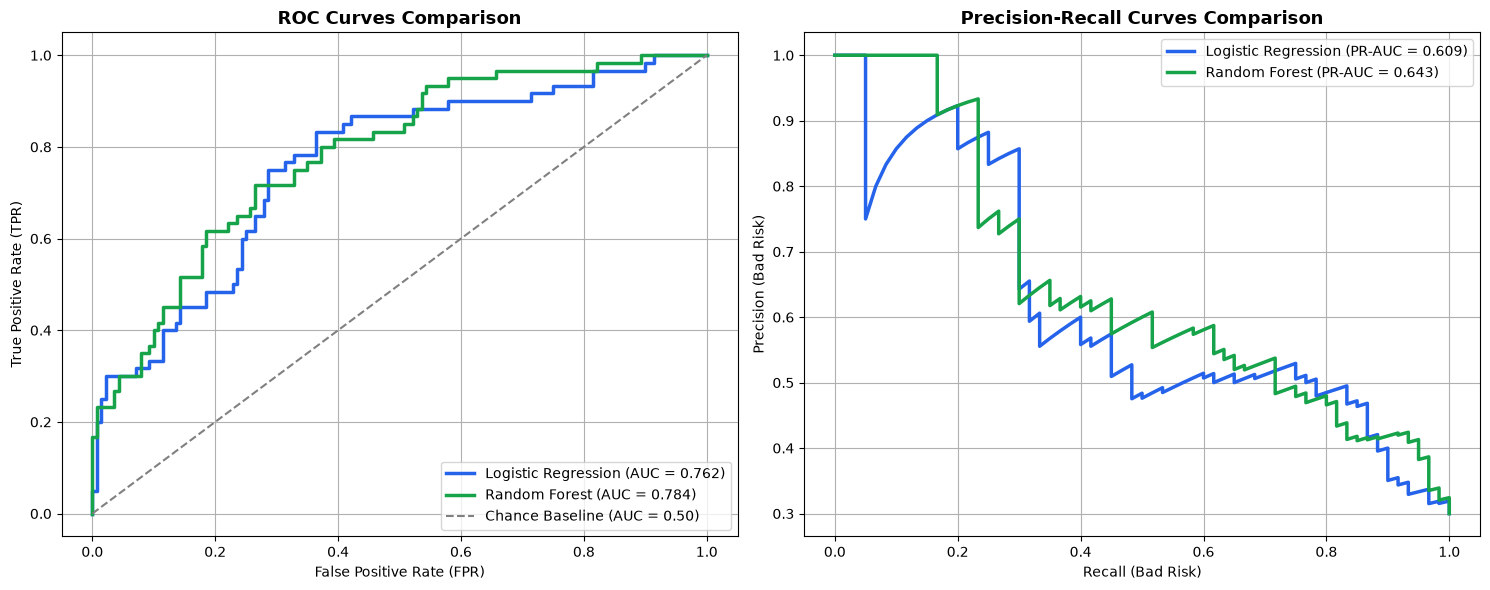

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

axes[0].plot(lr_fpr, lr_tpr, color='#2563eb', lw=2.5, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})")
axes[0].plot(rf_fpr, rf_tpr, color='#16a34a', lw=2.5, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_proba):.3f})")
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label="Chance Baseline (AUC = 0.50)")
axes[0].set_title("ROC Curves Comparison", fontsize=13, fontweight='bold')
axes[0].set_xlabel("False Positive Rate (FPR)")
axes[0].set_ylabel("True Positive Rate (TPR)")
axes[0].legend(loc="lower right")
axes[0].grid(True)

# Precision-Recall Curves
lr_prec_curve, lr_rec_curve, _ = precision_recall_curve(y_test, lr_proba)
rf_prec_curve, rf_rec_curve, _ = precision_recall_curve(y_test, rf_proba)

axes[1].plot(lr_rec_curve, lr_prec_curve, color='#2563eb', lw=2.5, label=f"Logistic Regression (PR-AUC = {auc(lr_rec_curve, lr_prec_curve):.3f})")
axes[1].plot(rf_rec_curve, rf_prec_curve, color='#16a34a', lw=2.5, label=f"Random Forest (PR-AUC = {auc(rf_rec_curve, rf_prec_curve):.3f})")
axes[1].set_title("Precision-Recall Curves Comparison", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Recall (Bad Risk)")
axes[1].set_ylabel("Precision (Bad Risk)")
axes[1].legend(loc="upper right")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Synthesis & Architectural Recommendation
### Why Random Forest Outperforms Logistic Regression
1. **Non-Linear Decision Boundaries**: Loan risk is inherently non-linear; for example, a high credit amount is safe for established applicants with rich savings, but risky for young or low-checking applicants. Random Forest captures these multi-feature split boundaries without manual interaction term engineering.
2. **Robustness to Collinearity**: Decision trees partition feature space orthogonally, avoiding variance inflation caused by correlations between duration and credit amount.
3. **Superior Discriminative Separation**: Random Forest yields a significantly higher ROC-AUC and Precision-Recall profile, leading to fewer costly false negatives (approving borrowers who default).

### Recommendation
- **Default Production Engine**: Use **Random Forest** for primary automated underwriting decisions.
- **Regulatory / Interpretability Backup**: Retain **Logistic Regression** where explicit per-feature linear log-odds coefficients are required by compliance regulators.